In [24]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [26]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [25]:
print(df.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [27]:
X = df.drop('Class', axis=1)
y = df['Class']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
print(y_train.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64


In [30]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [31]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [32]:
print(y_train_smote.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [33]:
import pandas as pd

balanced_df = pd.DataFrame(
    X_train_smote,
    columns=X.columns
)

balanced_df['Class'] = y_train_smote

balanced_df.to_csv(
    'creditcard_smote_balanced.csv',
    index=False
)

print("Balanced dataset saved.")

Balanced dataset saved.


In [35]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


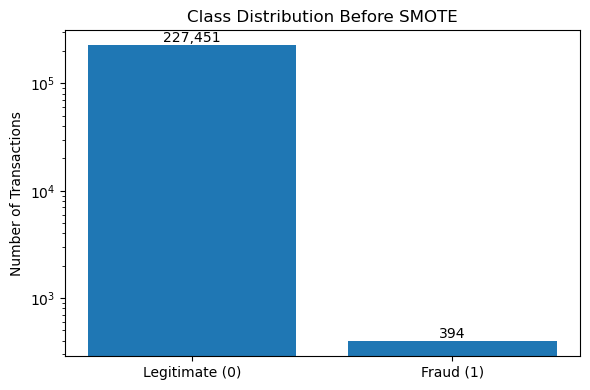

In [45]:
import matplotlib.pyplot as plt

before = [227451, 394]
classes = ['Legitimate (0)', 'Fraud (1)']

plt.figure(figsize=(6,4))

bars = plt.bar(classes, before)

plt.title('Class Distribution Before SMOTE')
plt.ylabel('Number of Transactions')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom'
    )

plt.yscale('log')
plt.tight_layout()
plt.show()

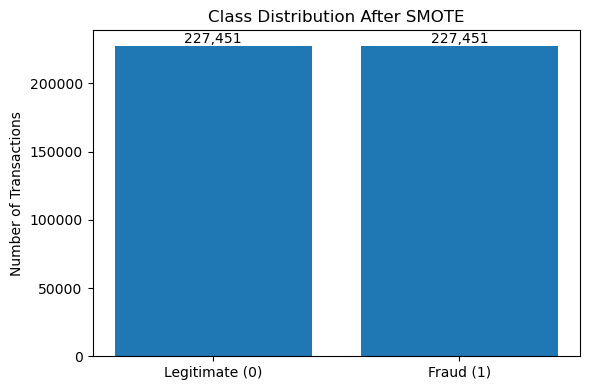

In [42]:
import matplotlib.pyplot as plt

after = [227451, 227451]
classes = ['Legitimate (0)', 'Fraud (1)']

plt.figure(figsize=(6,4))

bars = plt.bar(classes, after)

plt.title('Class Distribution After SMOTE')
plt.ylabel('Number of Transactions')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [ ]:
#overfitting problem if the variance/deviation/discrepancy is tooo high